In [1]:
import geopandas as gpd
import ee
import xee
import numpy as np
import xarray as xr
import os
from glob import glob
import matplotlib.pyplot as plt

### Select Scan ID

In [2]:
scan_id = "2025-12-senegal-dakar"
cityname  = scan_id.split('-')[-1] 

aoi_dir = os.path.join('mnt', scan_id, '01-user-input', 'AOI')
aoi_dir
aoi_file = glob(aoi_dir + "/*.shp")
print(aoi_file)


['mnt/2025-12-senegal-dakar/01-user-input/AOI/dakar-fua.shp', 'mnt/2025-12-senegal-dakar/01-user-input/AOI/South_Jakarta-Jakarta.shp']


In [3]:
aoi = gpd.read_file(aoi_file[0])
aoi

,eFUA_ID,UC_num,UC_IDs,eFUA_name,Commuting,Cntry_ISO,Cntry_name,FUA_area,UC_area,FUA_p_2015,UC_p_2015,Com_p_2015,geometry
0,153.0,1.0,1452,Dakar,1.0,SEN,Senegal,388.0,277.0,3.409806e+06,3.358310e+06,51496.882791,"POLYGON ((-1696000 1825000, -1695000 1825000, ..."


### Load yaml to get first and last year

In [4]:
import yaml
city_inputs_dir = os.path.join('mnt', scan_id, '01-user-input', 'city_inputs.yml')
city_inputs_dir

with open(city_inputs_dir) as f:
      config = yaml.safe_load(f)

print(config['first_year'], config['last_year'])

2015 2024


### Loading datasets from Task

Loading airquality data from gcs

In [5]:
import tasks.air_quality.datacollection as aq

In [6]:
aq_raster, aq_meta = aq.datacollection(aoi.to_crs(4326), config['city_name'], output_dir = 'temp', return_raster = True)

2026-02-16 18:08:23,995 | INFO | tasks.air_quality.datacollection | datacollection.py:35 | Starting Air Quality data collection…
2026-02-16 18:08:23,996 | INFO | tasks.air_quality.datacollection | datacollection.py:47 | AOI CRS: EPSG:4326
2026-02-16 18:08:23,996 | INFO | tasks.air_quality.datacollection | datacollection.py:56 | Requesting air quality raster: https://storage.googleapis.com/city-scan-global-public/air_quality/sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2019.tif
2026-02-16 18:08:25,027 | INFO | tasks.air_quality.datacollection | datacollection.py:60 | air quality raster opened successfully.
2026-02-16 18:08:25,580 | INFO | tasks.air_quality.datacollection | datacollection.py:94 | Clipped airquality saved to: temp/spatial/dakar_air.tif
2026-02-16 18:08:25,581 | INFO | tasks.air_quality.datacollection | datacollection.py:99 | airquality complete.


In [7]:
aq_raster

array([[[ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
          0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
          0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
          0. ,  0. ,  0. ,  0. ,  0. ,  0. ],
        [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
          0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
          0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
          0. ,  0. ,  0. ,  0. ,  0. ,  0. ],
        [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
          0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
          0. , 48.1, 47.6, 48. , 48.2, 48.5, 48.4,  0. ,  0. ,  0. ,
          0. ,  0. ,  0. ,  0. ,  0. ,  0. ],
        [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
          0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
          0. , 47.6, 47.5, 47.8, 48.3, 48.5, 48.2,  0. ,  0. ,  0. ,
          0. ,  0. ,  0. ,  0. ,  

In [8]:
aq_raster.shape

(1, 20, 36)

In [9]:
aq_meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': 0,
 'width': 36,
 'height': 20,
 'count': 1,
 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'),
 'transform': Affine(0.01, 0.0, -17.539999999999992,
        0.0, -0.01, 14.839999999999996)}

### Interactive Mapping

In [10]:
# https://leafmap.org
# !pip install leafmap
# !pip install localtileserver
# !pip install xarray_leaflet

import leafmap

In [ ]:
# load map
m = leafmap.Map()

# add Layers
m.add_raster('temp/spatial/dakar_air.tif', colormap='YlOrRd', layer_name='Air Quality', nodata = 0)
m.add_gdf(aoi, layer_name="AOI", style={'color': 'black', 'fillOpacity': 0})

# Center the map on the AOI
centroid = aoi.to_crs(4326).geometry.centroid
m.set_center(centroid.x.values[0], centroid.y.values[0], zoom=11)

# display the map 
m

Map(center=[14.741773841713654, -17.356362605569508], controls=(ZoomControl(options=['position', 'zoom_in_text…

Exception in thread Thread-365 (bg_main):
Traceback (most recent call last):
  File "/var/folders/3l/jxlbywk944n4gwvl6pj216j00000gn/T/ipykernel_90767/4192236062.py", line 17, in bg_main
  File "/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/IPython/core/display_functions.py", line 374, in update
    update_display(obj, display_id=self.display_id, **kwargs)
  File "/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/IPython/core/display_functions.py", line 326, in update_display
    display(obj, display_id=display_id, **kwargs)
  File "/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/IPython/core/display_functions.py", line 296, in display
    publish_display_data(data=obj, metadata=metadata, **kwargs)
  File "/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/IPython/core/display_functions.py", line 93, in publish_display_data
    display_pub.publish(
  File "/Users/vivaldirinaldi/m

Use helper functions in tasks/gee/fns

### GEE and Xarray

In [12]:
from tasks.gee import fns

In [ ]:
# Initialize Earth Engine
ee.Authenticate()
ee.Initialize(project = "", # use your own project here
              opt_url='https://earthengine-highvolume.googleapis.com')

### Transform Geopanda polygon to EE object

In [14]:
AOI, bounds = fns.aoi_to_ee_geometry(aoi)
print(bounds.getInfo())

{'geodesic': False, 'type': 'Polygon', 'coordinates': [[[-17.531122905983473, 14.643281131032172], [-17.181984816489603, 14.643281131032172], [-17.181984816489603, 14.831694176462983], [-17.531122905983473, 14.831694176462983], [-17.531122905983473, 14.643281131032172]]]}


In [15]:
criteria = fns.create_criteria(bounds, config['first_year'], config['last_year'])

### Try this out and this will take forever

In [16]:
col = ee.ImageCollection('COPERNICUS/S2_HARMONIZED')    \
    .filter(criteria)

In [17]:
# ds = xr.open_dataset(col, engine='ee', geometry=AOI, scale=10, projection=mcol.first().projection())

This function tries to load all Sentinel 2 dataset avaiable for the AOI within first and last years, since sentinel 2 images are per 5 days, therefore there will be this many image:

In [18]:
365 / 5 * (config['last_year'] - config['first_year'])

657.0

## Okay, we need a better temporal indexing

#### Building Seasonal Data

*Refer to tasks/gee/fns.py - _get_seasonal_months*

The original gee_fun.py uses CRU dataset to determine seasonal months. This data is stored in GCP and need updating. So, let's replace with ERA5, rasterized weather dataset with higher resoluition and near real-time collection

In [19]:
## lets use this dataset to familiarize ourselves with xarray and the ee engine

era5 = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR') \
    .select('temperature_2m') \
    .filter(criteria)

ds = xr.open_dataset(era5, 
                     engine='ee', 
                     geometry=AOI, 
                     scale=11132,
                     projection=era5.first().projection())


xarray is essentially 3D named array, here we have time, lon (longitude), lat (latitude)

In [20]:
ds

<xarray.Dataset> Size: 4kB
Dimensions:         (time: 120, lon: 3, lat: 2)
Coordinates:
  * time            (time) datetime64[ns] 960B 2015-01-01 ... 2024-12-01
  * lon             (lon) float64 24B -17.48 -17.38 -17.28
  * lat             (lat) float64 16B 14.78 14.68
Data variables:
    temperature_2m  (time, lon, lat) float32 3kB ...
Attributes:
    crs:      EPSG:4326

In [21]:
# just like pandas, we can do groupby operations on xarray datasets. Here we compute the monthly average temperature across the AOI for each month of the year (averaging across all years in the dataset)
monthly_avg = ds['temperature_2m'].groupby('time.month').mean()

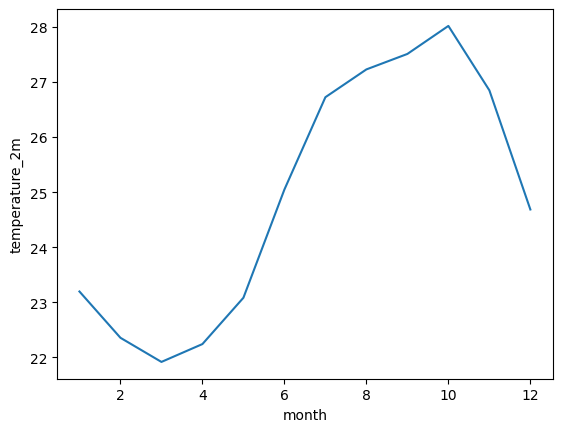

In [22]:
(monthly_avg.mean(dim=['lon', 'lat']) - 273.15).plot() # convert from K to C 

### Using Composite in task/gee/fns.py

The Composite class can be used to create temporal composite for ee.Image Collection - this needs to hapen in the Server-side since we are indexing many images

In [24]:
comp = fns.Composite(col, AOI, config['first_year'], config['last_year'])

In [25]:
comp._get_seasonal_months('summer')  # this will calculate the hottest month in AOI

[8, 9, 10]

In [27]:
summer_comp = comp.seasonal('summer', 'median')
# summer_comp.getInfo()

In [28]:
# lets get the image for summer

summer_image = xr.open_dataset(summer_comp, 
                     engine='ee', 
                     geometry=AOI, 
                     scale=100, # natively its 10m but we can use a coarser scale for faster processing
                     crs='EPSG:3857'
                     )


In [29]:
summer_image.dims

FrozenMappingWarningOnValuesAccess({'time': 1, 'X': 389, 'Y': 217})

In [30]:
summer_image

<xarray.Dataset> Size: 6MB
Dimensions:              (time: 1, X: 389, Y: 217)
Coordinates:
  * time                 (time) int64 8B 0
  * X                    (X) float64 3kB -1.952e+06 -1.951e+06 ... -1.913e+06
  * Y                    (Y) float64 2kB 1.648e+06 1.648e+06 ... 1.67e+06
Data variables: (12/19)
    B1                   (time, X, Y) float32 338kB ...
    B2                   (time, X, Y) float32 338kB ...
    B3                   (time, X, Y) float32 338kB ...
    B4                   (time, X, Y) float32 338kB ...
    B5                   (time, X, Y) float32 338kB ...
    B6                   (time, X, Y) float32 338kB ...
    ...                   ...
    QA10                 (time, X, Y) float32 338kB ...
    QA20                 (time, X, Y) float32 338kB ...
    QA60                 (time, X, Y) float32 338kB ...
    MSK_CLASSI_OPAQUE    (time, X, Y) float32 338kB ...
    MSK_CLASSI_CIRRUS    (time, X, Y) float32 338kB ...
    MSK_CLASSI_SNOW_ICE  (time, X, Y) float32 338kB ...
Attributes:
    crs:      EPSG:3857

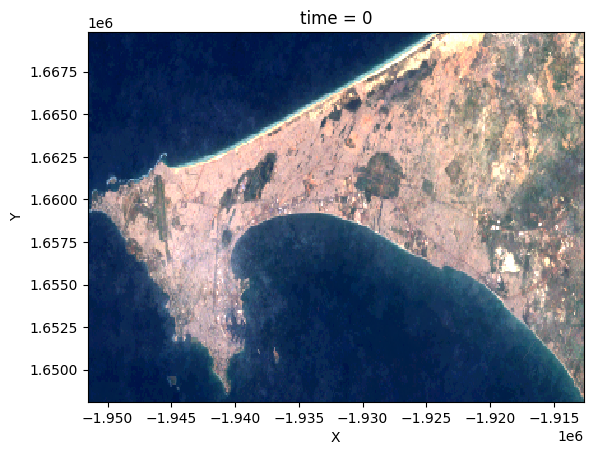

In [31]:
summer_image[['B4', 'B3','B2']].to_array().squeeze().transpose().plot.imshow(robust=True)

### Calculate NDVI

In [32]:
ndvi = (summer_image['B8'] - summer_image['B4']) / (summer_image['B8'] + summer_image['B4'])

In [33]:
ndvi.dims

('time', 'X', 'Y')

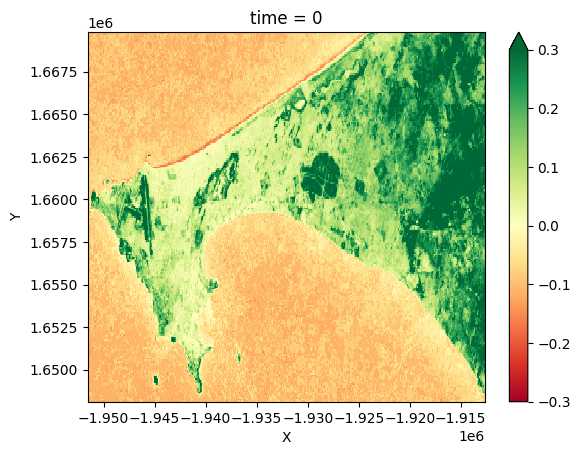

In [34]:
ndvi.squeeze().transpose().plot.imshow(cmap='RdYlGn', robust=True, vmin=-0.3, vmax=0.3)

In [35]:
ndvi

<xarray.DataArray (time: 1, X: 389, Y: 217)> Size: 338kB
array([[[-0.12192181, -0.11842173, -0.11099497, ..., -0.09607106,
         -0.10109041, -0.08577451],
        [-0.11482169, -0.11609308, -0.11509021, ..., -0.09199994,
         -0.11010315, -0.08961859],
        [-0.114521  , -0.10891996, -0.08546764, ..., -0.11724804,
         -0.08796984, -0.08902214],
        ...,
        [-0.04755203, -0.01752867, -0.08117983, ...,  0.2538649 ,
          0.30530176,  0.35667333],
        [-0.08748153, -0.08035193, -0.07646374, ...,  0.27508625,
          0.24630247,  0.25565484],
        [-0.07219259, -0.04765349, -0.07518526, ...,  0.2606548 ,
          0.26580635,  0.26183105]]], dtype=float32)
Coordinates:
  * time     (time) int64 8B 0
  * X        (X) float64 3kB -1.952e+06 -1.951e+06 ... -1.913e+06 -1.913e+06
  * Y        (Y) float64 2kB 1.648e+06 1.648e+06 1.648e+06 ... 1.67e+06 1.67e+06

In [36]:
ndvi.rio.crs

In [37]:
ndvi_r = fns.xee_to_rio(ndvi)
print(ndvi_r.rio.crs)

EPSG:4326


In [38]:
m.add_raster(ndvi_r, colormap='RdYlGn', layer_name='NDVI', vmin=-0.3, vmax=0.2, array_args={"dtype": "float32"})
m

Map(bottom=240734.0, center=[14.7377605, -17.356410500000003], controls=(ZoomControl(options=['position', 'zoo…

## Other composite functions

In [39]:
monthly_comp = comp.monthly('median')

In [40]:
monthly = xr.open_dataset(monthly_comp, 
                     engine='ee', 
                     geometry=AOI, 
                     scale=100, # natively its 10m but we can use a coarser scale for faster processing
                     crs='EPSG:3857'
                     )


In [41]:
monthly.dims

FrozenMappingWarningOnValuesAccess({'time': 12, 'X': 389, 'Y': 217})

In [42]:
monthly

<xarray.Dataset> Size: 77MB
Dimensions:              (time: 12, X: 389, Y: 217)
Coordinates:
  * time                 (time) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * X                    (X) float64 3kB -1.952e+06 -1.951e+06 ... -1.913e+06
  * Y                    (Y) float64 2kB 1.648e+06 1.648e+06 ... 1.67e+06
Data variables: (12/19)
    B1                   (time, X, Y) float32 4MB ...
    B2                   (time, X, Y) float32 4MB ...
    B3                   (time, X, Y) float32 4MB ...
    B4                   (time, X, Y) float32 4MB ...
    B5                   (time, X, Y) float32 4MB ...
    B6                   (time, X, Y) float32 4MB ...
    ...                   ...
    QA10                 (time, X, Y) float32 4MB ...
    QA20                 (time, X, Y) float32 4MB ...
    QA60                 (time, X, Y) float32 4MB ...
    MSK_CLASSI_OPAQUE    (time, X, Y) float32 4MB ...
    MSK_CLASSI_CIRRUS    (time, X, Y) float32 4MB ...
    MSK_CLASSI_SNOW_ICE  (time, X, Y) float32 4MB ...
Attributes:
    crs:      EPSG:3857

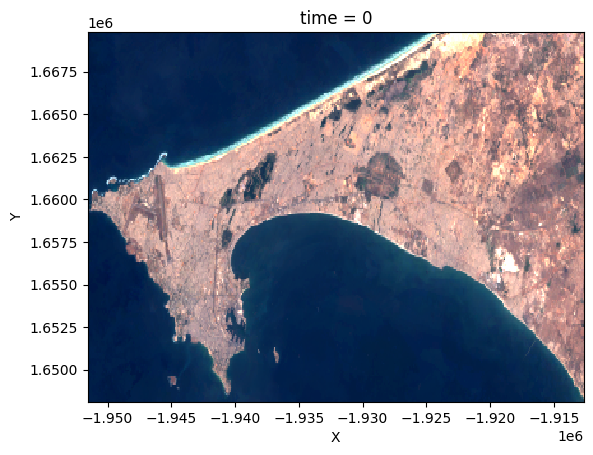

In [43]:
monthly.isel(time=0)[['B4', 'B3','B2']].to_array().squeeze().transpose().plot.imshow(robust=True)

In [44]:
def calculate_ndvi(image):
    return (image['B8'] - image['B4']) / (image['B8'] + image['B4'])

In [45]:
ndvi_monthly = calculate_ndvi(monthly)

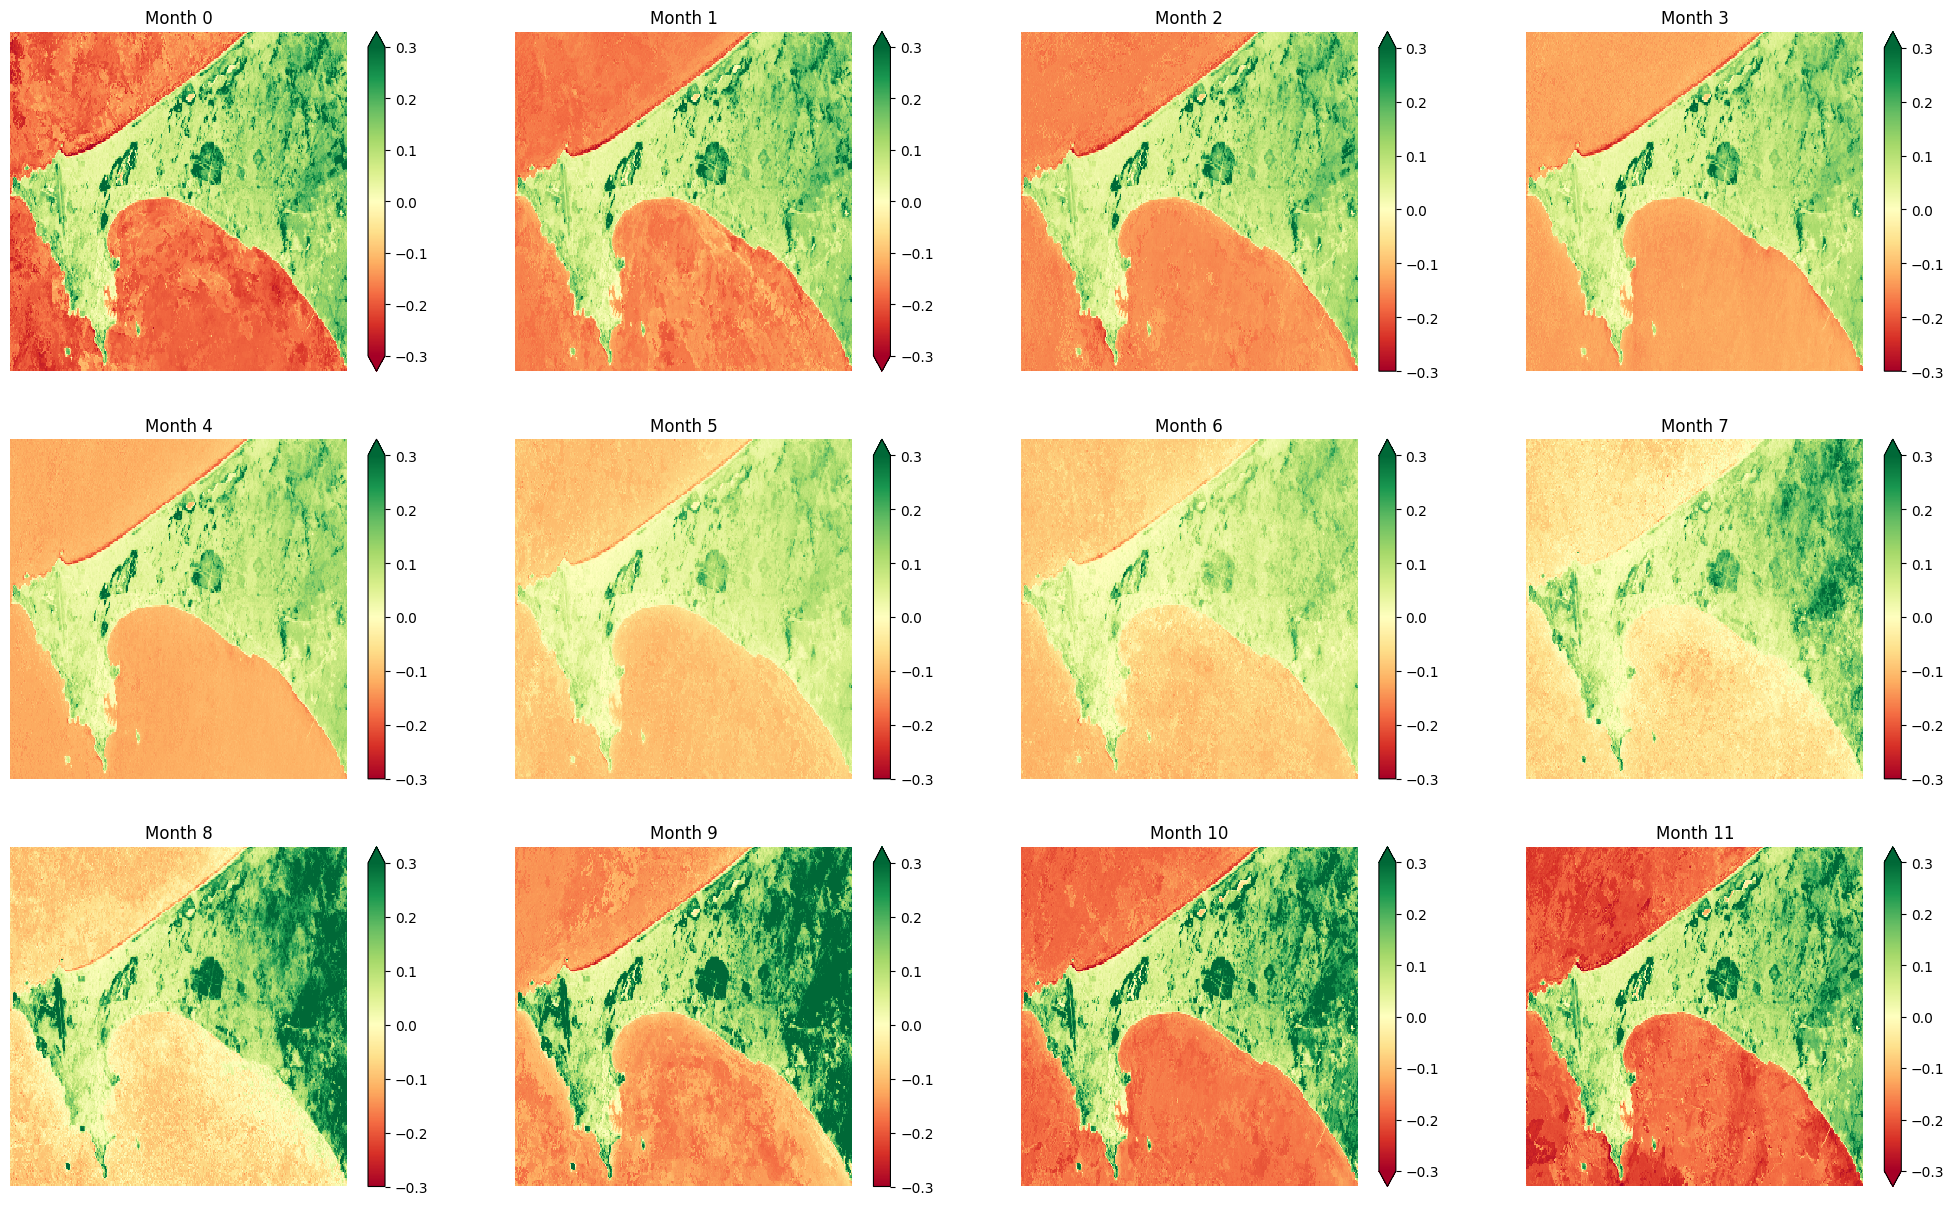

In [46]:
plt.figure(figsize=(25, 15))
for i in range(len(monthly.time)):

    plt.subplot(3, 4, i+1)

    # img = monthly.isel(time=i)
    # ndvi = calculate_ndvi(img)
    ndvi = ndvi_monthly.isel(time=i)

    ndvi.squeeze(drop=True).transpose().plot.imshow(cmap='RdYlGn', robust=True, vmin=-0.3, vmax=0.3)
    plt.axis('off')
    plt.title(f"Month {ndvi['time'].values}")


## Add other dataset to the map

In [110]:
from tasks.gee import landcover, forest, elevation, lst, nightlight

#### Landcover

In [69]:
lc, lc_stat = landcover.datacollection(aoi.to_crs(4326), config['city_name'], output_dir = 'temp', return_raster = True)

2026-02-16 19:47:27,454 | INFO | tasks.gee.landcover | landcover.py:37 | Starting Land Cover data collection...
2026-02-16 19:47:31,414 | INFO | tasks.gee.landcover | landcover.py:82 | Land cover stats saved to: temp/tabular/dakar_lc.csv
2026-02-16 19:47:34,084 | INFO | tasks.gee.landcover | landcover.py:96 | Land cover raster saved to: temp/spatial/dakar_lc.tif


In [71]:
lc = lc.rio.clip(aoi.to_crs(epsg=4326).geometry)

In [77]:
lc

<xarray.DataArray 'Map' (y: 2114, x: 3917)> Size: 33MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * x            (x) float64 31kB -17.53 -17.53 -17.53 ... -17.18 -17.18 -17.18
  * y            (y) float64 17kB 14.83 14.83 14.83 14.83 ... 14.64 14.64 14.64
    spatial_ref  int64 8B 0
Attributes:
    id:             Map
    data_type:      {'type': 'PixelType', 'precision': 'int', 'min': 0, 'max'...
    dimensions:     [4320000, 1728000]
    crs_transform:  [8.333333333333333e-05, 0, -180, 0, -8.333333333333333e-0...
    _FillValue:     nan

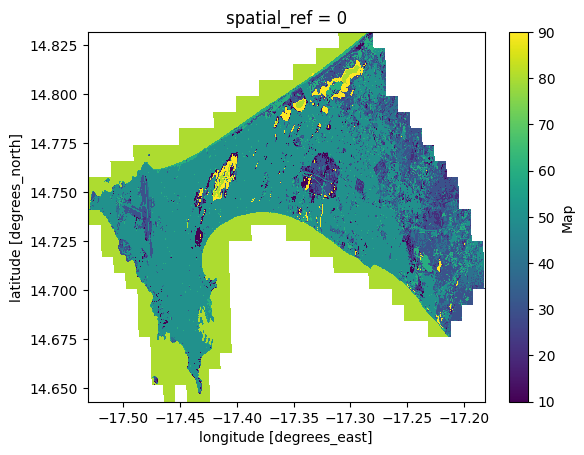

In [74]:
lc.plot()

In [81]:
fc23, defor = forest.datacollection(aoi.to_crs(4326), config['city_name'], output_dir = 'temp', return_raster = True)

2026-02-16 19:58:02,689 | INFO | tasks.gee.forest | forest.py:21 | Starting Forest data collection...
/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/ee/deprecation.py:209: DeprecationWarning: 

Attention required for UMD/hansen/global_forest_change_2023_v1_11! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/UMD_hansen_global_forest_change_2023_v1_11

  warnings.warn(warning, category=DeprecationWarning)
2026-02-16 19:58:04,916 | INFO | tasks.gee.forest | forest.py:75 | Forest cover raster saved to: temp/spatial/dakar_forest_cover23.tif
2026-02-16 19:58:05,577 | INFO | tasks.gee.forest | forest.py:81 | Deforestation raster saved to: temp/spatial/dakar_deforestation.tif


#### Forest

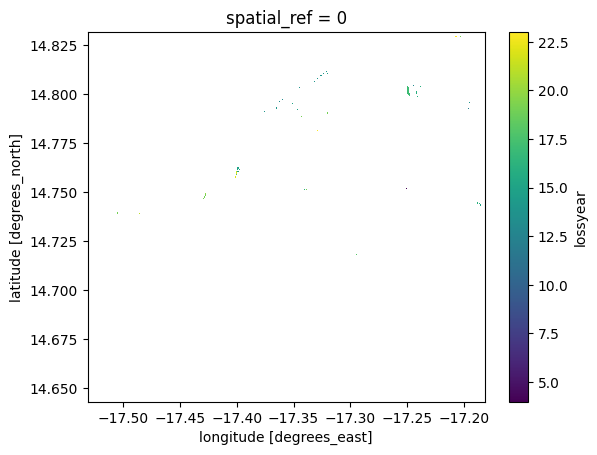

In [115]:
defor.plot()

#### Elevation

In [88]:
elev, elev_buf = elevation.datacollection(aoi.to_crs(4326), config['city_name'], output_dir = 'temp', return_raster = True)

2026-02-16 20:02:18,208 | INFO | tasks.gee.elevation | elevation.py:22 | Starting Elevation data collection...
2026-02-16 20:02:20,069 | INFO | tasks.gee.elevation | elevation.py:67 | Elevation raster saved to: temp/spatial/dakar_elevation.tif
2026-02-16 20:02:20,595 | INFO | tasks.gee.elevation | elevation.py:73 | Buffered elevation raster saved to: temp/spatial/dakar_elevation_buf.tif


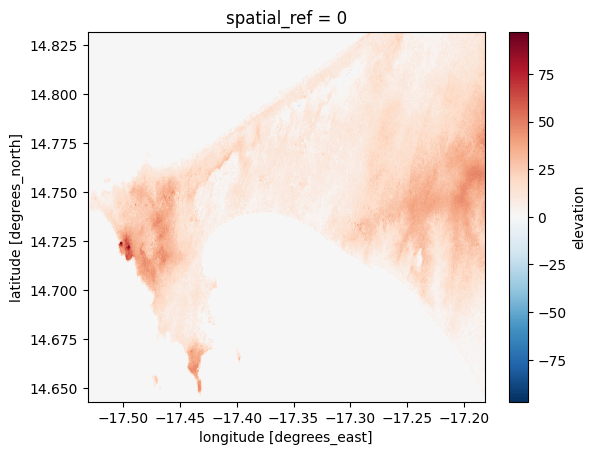

In [89]:
elev.plot()

#### Land Surface Temperature

In [118]:
lst_data = lst.datacollection(aoi.to_crs(4326), config['city_name'], output_dir = 'temp', composite = ['summer', 'winter'], return_raster = True)

2026-02-16 20:24:54,328 | INFO | tasks.gee.lst | lst.py:34 | Starting LST data collection...
2026-02-16 20:25:06,137 | INFO | tasks.gee.lst | lst.py:77 | Saved summer LST: temp/spatial/dakar_lst_summer.tif
2026-02-16 20:25:20,422 | INFO | tasks.gee.lst | lst.py:77 | Saved winter LST: temp/spatial/dakar_lst_winter.tif


In [119]:
lst_data.keys()

dict_keys(['summer', 'winter'])

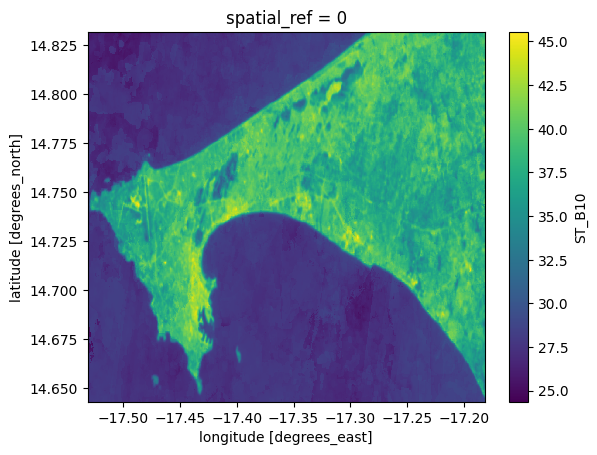

In [120]:
lst_data['summer'].plot()

#### Nightlight

In [121]:
nl = nightlight.datacollection(aoi.to_crs(4326), config['city_name'], output_dir = 'temp', return_raster = True)

nl.keys()

2026-02-16 20:25:21,179 | INFO | tasks.gee.nightlight | nightlight.py:21 | Starting nightlight data collection...
2026-02-16 20:25:22,081 | INFO | tasks.gee.nightlight | nightlight.py:64 | Saved linear fit: temp/spatial/dakar_linfit.tif
2026-02-16 20:25:22,902 | INFO | tasks.gee.nightlight | nightlight.py:83 | Saved sum of lights: temp/spatial/dakar_avg_rad_sum.tif


dict_keys(['linfit', 'avg_rad_sum'])

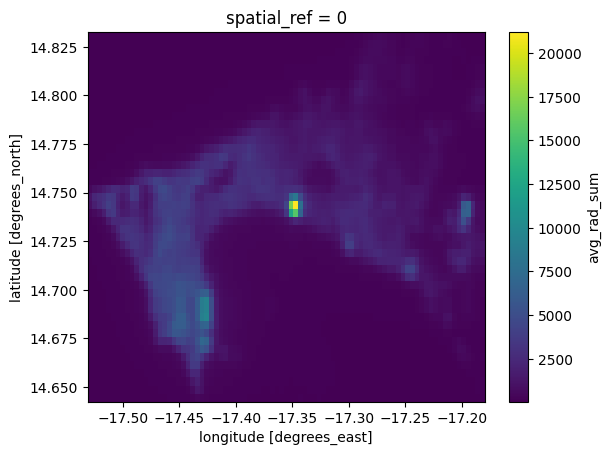

In [122]:
nl['avg_rad_sum'].plot()

## Add them all to a new map

In [125]:
m = leafmap.Map()
m.add_raster(lc, colormap='tab10', layer_name='Landcover', vmin=10, vmax=100, array_args={"dtype": "float32", "nodata": np.nan})

m.add_raster(elev, colormap='jet', layer_name='Elevation', vmin=0, vmax=50, array_args={"dtype": "float32", "nodata": np.nan})

m.add_raster(lst_data['summer'], colormap='inferno', layer_name='LST Summer', vmin=20, vmax=40, array_args={"dtype": "float32", "nodata": np.nan})

m.add_raster(nl['avg_rad_sum'], colormap='gray', layer_name='Nightlight', vmin=0, vmax=10000, array_args={"dtype": "float32", "nodata": np.nan})


m

Map(center=[14.73758, -17.355411500000002], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_i…